In [1]:
# import tensorflow as tf
# from sklearn.datasets import load_sample_images
# import numpy as np
# import matplotlib.pyplot as plt

# # https://stackoverflow.com/questions/41429479/tensorflow-resize-image-changes-color

# images = load_sample_images()["images"]

# image_1 = tf.keras.layers.Resizing(height=700, width=700,crop_to_aspect_ratio=False)(images[0])
# image_1 = tf.keras.layers.Rescaling(1./255, offset=0)(image_1)

# plt.imshow(image_1)

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_images

In [3]:
print(tf.__version__)

2.9.2


In [4]:
#Load data 
cifar_10 = tf.keras.datasets.cifar10

(x_train, y_train), (x_test, y_test) = cifar_10.load_data()

In [5]:
x_train.shape, y_train.shape

((50000, 32, 32, 3), (50000, 1))

In [6]:
#Rescale values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

In [7]:
# Flatten labels to be an array
y_train, y_test = y_train.flatten(), y_test.flatten()

In [8]:
#Split train set to have validation set
x_train, x_valid = x_train[:40_000], x_train[40_000:]
y_train, y_valid = y_train[:40_000], y_train[40_000:]

In [9]:
#Number of unique classes
K = len(set(y_train))
K

10

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, input_shape=x_train[0].shape, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(), 

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=1024, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=10, activation="softmax")
])

In [11]:
#Learning rate scheduling
import math
batch_size = 32
n_epochs = 100

n_steps = n_epochs * math.ceil(len(x_train) / batch_size)
scheduled_learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
initial_learning_rate=0.001, decay_steps=n_steps, decay_rate=0.01)

optimizer = tf.keras.optimizers.Adam(learning_rate=scheduled_learning_rate)

In [12]:
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
checkpoint_filepath = 'my_checkpoint'

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, save_best_only=True, save_weights_only=True, save_freq='epoch')
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True)

In [14]:
#Data augmentation
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
train_generator = data_generator.flow(x_train, y_train, batch_size)
steps_per_epoch = x_train.shape[0] // batch_size

r = model.fit(train_generator, validation_data=(x_valid, y_valid), steps_per_epoch=steps_per_epoch, epochs=100, callbacks=[checkpoint_cb])

Epoch 1/100
1250/1250 [==============================] - 40s 23ms/step - loss: 1.5348 - accuracy: 0.4658 - val_loss: 1.1252 - val_accuracy: 0.5977
Epoch 2/100
1250/1250 [==============================] - 28s 23ms/step - loss: 1.0758 - accuracy: 0.6205 - val_loss: 1.0423 - val_accuracy: 0.6422
Epoch 3/100
1250/1250 [==============================] - 29s 23ms/step - loss: 0.9145 - accuracy: 0.6816 - val_loss: 0.7855 - val_accuracy: 0.7285
Epoch 4/100
1250/1250 [==============================] - 28s 23ms/step - loss: 0.8089 - accuracy: 0.7190 - val_loss: 0.7174 - val_accuracy: 0.7480
Epoch 5/100
1250/1250 [==============================] - 28s 22ms/step - loss: 0.7324 - accuracy: 0.7470 - val_loss: 0.6988 - val_accuracy: 0.7640
Epoch 6/100
1250/1250 [==============================] - 27s 22ms/step - loss: 0.6641 - accuracy: 0.7723 - val_loss: 0.6261 - val_accuracy: 0.7869
Epoch 7/100
1250/1250 [==============================] - 28s 22ms/step - loss: 0.6205 - accuracy: 0.7872 - val_loss: 0

In [15]:
#r = model.fit(x_train, y_train, validation_split=0.33, epochs=100, callbacks=[checkpoint_cb])

In [16]:
for key in r.history:
  print(key)

loss
accuracy
val_loss
val_accuracy


In [17]:
model.load_weights(checkpoint_filepath)

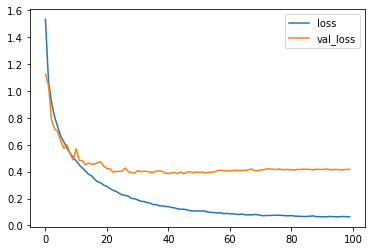

In [18]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend();

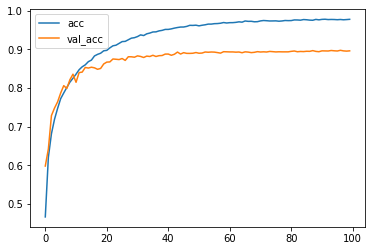

In [19]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend();

In [20]:
max(r.history['val_accuracy'])

0.8977000117301941

In [21]:
print(model.evaluate(x_test, y_test))

313/313 [==============================] - 1s 4ms/step - loss: 0.4083 - accuracy: 0.8858
[0.4083442986011505, 0.8858000040054321]


313/313 [==============================] - 1s 3ms/step
Confusion matrix, without normalization


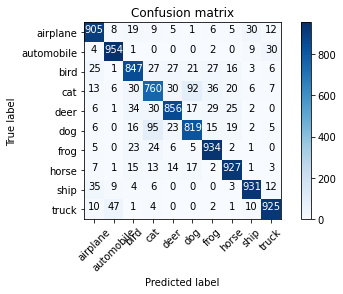

In [22]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """
  This function prints and plots the confusion matrix.
  Normalization can be applied by setting `normalize=True`.
  """
  if normalize:
      cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
      print("Normalized confusion matrix")
  else:
      print('Confusion matrix, without normalization')

 # print(cm)

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt),
               horizontalalignment="center",
               color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()


p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)

classes = ('airplane', 
           'automobile', 
           'bird',
           'cat',
           'deer',
           'dog', 
           'frog', 
           'horse', 
           'ship',
           'truck')

plot_confusion_matrix(cm, classes)

In [27]:
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

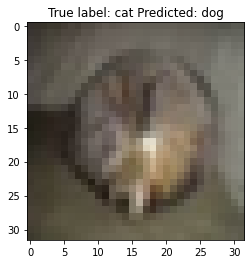

In [43]:
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]));

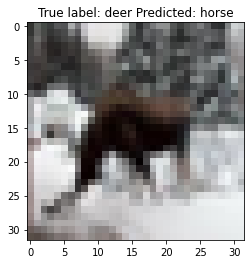

In [42]:
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]));

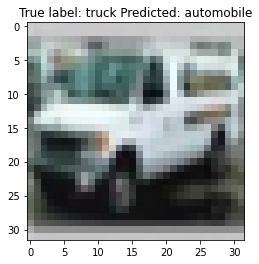

In [30]:
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]));

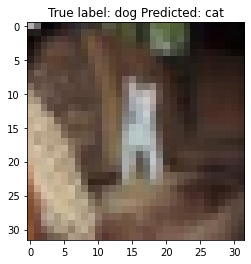

In [35]:
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]));

In [45]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 32, 32, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                        